In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import ipaddress
import scapy.all as scapy



In [6]:
ml = pd.read_csv("../exports/malware_traffic_extracted.csv")

In [7]:
ml.head

<bound method NDFrame.head of        timestamp_epoch        src_ip           dst_ip  src_port  dst_port  \
0         1.749829e+09       0.0.0.0  255.255.255.255        68        67   
1         1.749829e+09     10.6.13.3  255.255.255.255        67        68   
2         1.749829e+09       0.0.0.0  255.255.255.255        68        67   
3         1.749829e+09     10.6.13.3  255.255.255.255        67        68   
4         1.749829e+09   10.6.13.133        10.6.13.3     61943        53   
...                ...           ...              ...       ...       ...   
48610     1.749831e+09   10.6.13.133        10.6.13.3       123       123   
48611     1.749831e+09     10.6.13.3      10.6.13.133       123       123   
48612     1.749831e+09   10.6.13.133     104.21.112.1     52639        80   
48613     1.749831e+09  104.21.112.1      10.6.13.133        80     52639   
48614     1.749831e+09   10.6.13.133     104.21.112.1     52639        80   

      protocol  packet_length                

In [8]:

ml['timestamp'] = pd.to_datetime(ml['timestamp_epoch'], unit='s').dt.round('s')
ml['hour'] = ml['timestamp'].dt.hour
ml['minute'] = ml['timestamp'].dt.minute
ml = ml.sort_values(by='timestamp')
print("✅ Main 'timestamp' column has been cleaned and set as the basis.")
print("✅ Data sorted chronologically.")


# --- Analysis Commands ---
total_rows = len(ml)
total_cols = len(ml.columns)
duplicates = ml.duplicated().sum()
missing_vals = ml.isnull().sum().sum()

# Display Summary

print(f"Total Packets: {total_rows}")
print(f"Duplicate Packets: {duplicates}")
print(f"Missing Values: {missing_vals}")

# Display First 5 Rows
display(ml.head())

✅ Main 'timestamp' column has been cleaned and set as the basis.
✅ Data sorted chronologically.
Total Packets: 48615
Duplicate Packets: 217
Missing Values: 0


,timestamp_epoch,src_ip,dst_ip,src_port,dst_port,protocol,packet_length,flow_id,timestamp,hour,minute
0,1.749829e+09,0.0.0.0,255.255.255.255,68,67,UDP,344,0.0.0.0:68->255.255.255.255:67/UDP,2025-06-13 15:33:56,15,33
28,1.749829e+09,10.6.13.3,10.6.13.133,389,52427,TCP,1514,10.6.13.3:389->10.6.13.133:52427/TCP,2025-06-13 15:33:56,15,33
29,1.749829e+09,10.6.13.3,10.6.13.133,389,52427,TCP,1430,10.6.13.3:389->10.6.13.133:52427/TCP,2025-06-13 15:33:56,15,33
30,1.749829e+09,10.6.13.133,10.6.13.3,52427,389,TCP,60,10.6.13.133:52427->10.6.13.3:389/TCP,2025-06-13 15:33:56,15,33
31,1.749829e+09,10.6.13.133,10.6.13.3,52428,88,TCP,66,10.6.13.133:52428->10.6.13.3:88/TCP,2025-06-13 15:33:56,15,33


In [9]:

known_victims = ['10.6.13.133', '10.6.13.3', '10.6.13.33']
known_attackers = ['83.137.149.15'] 

internal_prefix = "10."

print("🛡️ Intelligence Configuration Loaded:")
print(f"   - Victims: {known_victims}")
print(f"   - Attackers: {known_attackers}")

def classify_ip_role(ip):
    if ip in known_victims:
        return 'Victim'
    if ip in known_attackers:
        return 'Attacker'
    if ip.startswith(internal_prefix):
        return 'Internal'
    return 'External'

print("🧠 Classifying IP Roles...")
ml['src_role'] = ml['src_ip'].apply(classify_ip_role)
ml['dst_role'] = ml['dst_ip'].apply(classify_ip_role)



🛡️ Intelligence Configuration Loaded:
   - Victims: ['10.6.13.133', '10.6.13.3', '10.6.13.33']
   - Attackers: ['83.137.149.15']
🧠 Classifying IP Roles...


In [10]:
# --- Feature 1: Is Malicious? ---
ml['is_malicious'] = (ml['src_role'] == 'Attacker') | (ml['dst_role'] == 'Attacker')
ml['is_malicious'] = ml['is_malicious'].astype(int)


In [11]:

# --- Feature 2: Direction (من منظور الضحية) ---
def get_direction(row):
    if row['src_role'] == 'Victim':
        return 'Outbound'
    elif row['dst_role'] == 'Victim':
        return 'Inbound'
    else:
        return 'Lateral'

ml['direction'] = ml.apply(get_direction, axis=1)


In [12]:

# --- Feature 3: Attack Stage ---
def get_attack_stage(row):
    if row['is_malicious'] == 0:
        return 'Normal Traffic'
    
    if row['dst_role'] == 'Victim':
        return 'Recon / Exploit'
    elif row['src_role'] == 'Victim':
        return 'C2 / Exfiltration'
    else:
        return 'Suspicious Lateral'

ml['attack_stage'] = ml.apply(get_attack_stage, axis=1)


In [13]:

# --- Feature 4: Human Time ---
ml['readable_time'] = pd.to_datetime(ml['timestamp_epoch'], unit='s')


# File 1: Raw Backup
ml.to_csv('../pcaps/malware_traffic_raw_backup.csv', index=False)

# File 2: Packet Level (Timeline Analysis)
packet_cols = [
    'timestamp_epoch', 'readable_time',
    'src_ip', 'src_role', 'dst_ip', 'dst_role',
    'src_port', 'dst_port', 'protocol', 'packet_length',
    'direction', 'is_malicious', 'attack_stage'
]
packet_intel = ml[packet_cols]
packet_intel.to_csv('../logs/malware_traffic_intel_packet.csv', index=False)

# File 3: Flow Level (Beaconing Analysis)
print("📉 Calculating Flow Stats...")
flow_stats = ml.groupby(['src_ip', 'src_role', 'dst_ip', 'dst_role', 'protocol', 'attack_stage']).agg(
    packet_count=('packet_length', 'count'),
    total_bytes=('packet_length', 'sum'),
    avg_packet_size=('packet_length', 'mean'),
    start_time=('timestamp_epoch', 'min'),
    end_time=('timestamp_epoch', 'max'),
    std_packet_size=('packet_length', 'std')
).reset_index()

flow_stats['duration_seconds'] = flow_stats['end_time'] - flow_stats['start_time']
flow_stats['frequency'] = np.where(
    flow_stats['duration_seconds'] > 0,
    flow_stats['packet_count'] / flow_stats['duration_seconds'],
    0
)

flow_stats.to_csv('../exports/malware_traffic_intel_flow.csv', index=False)

print("\n✅ Done! Files generated without reading external report files.")

📉 Calculating Flow Stats...

✅ Done! Files generated without reading external report files.


In [14]:
#Show a quick sample of attacks
ml[ml['is_malicious'] == 1][['readable_time', 'src_ip', 'dst_ip', 'attack_stage']].head()


,readable_time,src_ip,dst_ip,attack_stage
8530,2025-06-13 15:36:33.358478069,10.6.13.133,83.137.149.15,C2 / Exfiltration
8528,2025-06-13 15:36:33.347645044,83.137.149.15,10.6.13.133,Recon / Exploit
8529,2025-06-13 15:36:33.347821951,10.6.13.133,83.137.149.15,C2 / Exfiltration
8527,2025-06-13 15:36:33.200475931,10.6.13.133,83.137.149.15,C2 / Exfiltration
8631,2025-06-13 15:36:34.290030003,10.6.13.133,83.137.149.15,C2 / Exfiltration


In [15]:
victims_detected = ml[(ml['src_role'] == 'Victim') | (ml['dst_role'] == 'Victim')]['src_ip'].unique()

attackers_detected = ml[(ml['src_role'] == 'Attacker') | (ml['dst_role'] == 'Attacker')]['src_ip'].unique()

print(f"🎯 Victims Identified: {list(victims_detected)}")
print(f"⚔️  Attackers Identified: {list(attackers_detected)}")

🎯 Victims Identified: ['10.6.13.3', '10.6.13.133', '52.156.123.84', '23.192.223.206', '173.222.52.33', '104.208.203.90', '20.190.135.6', '204.79.197.203', '23.198.7.186', '13.107.42.16', '217.20.51.22', '23.212.185.76', '150.171.27.11', '40.126.29.13', '23.198.7.180', '150.171.28.11', '142.250.115.99', '173.194.208.155', '142.250.113.95', '142.251.186.138', '205.174.24.80', '142.250.138.97', '142.250.115.94', '142.250.115.106', '142.250.115.95', '173.194.208.94', '13.107.246.57', '67.217.228.199', '109.61.92.48', '142.250.138.155', '216.239.38.181', '23.96.124.68', '157.240.24.13', '44.239.34.26', '142.250.115.104', '157.240.24.35', '104.16.124.96', '204.79.197.222', '150.171.73.254', '191.232.215.149', '52.113.196.254', '172.202.65.254', '13.107.42.10', '13.107.18.254', '10.6.13.129', '20.189.173.6', '172.67.146.241', '104.21.24.186', '104.21.112.1', '23.212.185.87', '150.171.27.12', '23.198.7.168', '23.198.7.182', '83.137.149.15', '104.21.16.1', '104.16.230.132', '20.190.157.13', '23

In [16]:
malicious_traffic = ml[ml['is_malicious'] == 1]

start_time = malicious_traffic['readable_time'].min()
end_time = malicious_traffic['readable_time'].max()
duration = end_time - start_time
total_malicious_packets = len(malicious_traffic)

print(f"🕒 Attack Start Time: {start_time}")
print(f"🕒 Attack End Time:   {end_time}")
print(f"⏱️  Total Duration:   {duration}")
print(f"📦 Malicious Packets: {total_malicious_packets}")

🕒 Attack Start Time: 2025-06-13 15:36:33.200475931
🕒 Attack End Time:   2025-06-13 15:38:49.216980934
⏱️  Total Duration:   0 days 00:02:16.016505003
📦 Malicious Packets: 35485


In [17]:
stage_counts = ml['attack_stage'].value_counts()

print("🧩 Attack Stages Breakdown:")
print(stage_counts)

🧩 Attack Stages Breakdown:
attack_stage
Recon / Exploit      23281
Normal Traffic       13130
C2 / Exfiltration    12204
Name: count, dtype: int64


In [18]:
exfil_traffic = ml[
    (ml['direction'] == 'Outbound') & 
    (ml['is_malicious'] == 1)
]

total_exfil_bytes = exfil_traffic['packet_length'].sum()

total_exfil_mb = total_exfil_bytes / (1024 * 1024)

print(f"🚨 DATA EXFILTRATION DETECTED!")
print(f"📤 Total Volume Exfiltrated: {total_exfil_mb:.2f} MB")

🚨 DATA EXFILTRATION DETECTED!
📤 Total Volume Exfiltrated: 0.72 MB


In [19]:
malicious_flows = flow_stats[flow_stats['attack_stage'] != 'Normal Traffic']

suspected_beacons = malicious_flows.dropna(subset=['std_packet_size']).sort_values(by='std_packet_size', ascending=True)

print("🚨 SUSPECTED C2 BEACONS (Most Consistent Packets):")
print(suspected_beacons[['src_ip', 'dst_ip', 'protocol', 'packet_count', 'avg_packet_size', 'std_packet_size']].head(10))

🚨 SUSPECTED C2 BEACONS (Most Consistent Packets):
            src_ip         dst_ip protocol  packet_count  avg_packet_size  \
80     10.6.13.133  83.137.149.15      TCP         12204        61.819977   
153  83.137.149.15    10.6.13.133      TCP         23281      1429.125510   

     std_packet_size  
80          8.252874  
153        31.341569  


i:\date projects\malware traffic analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


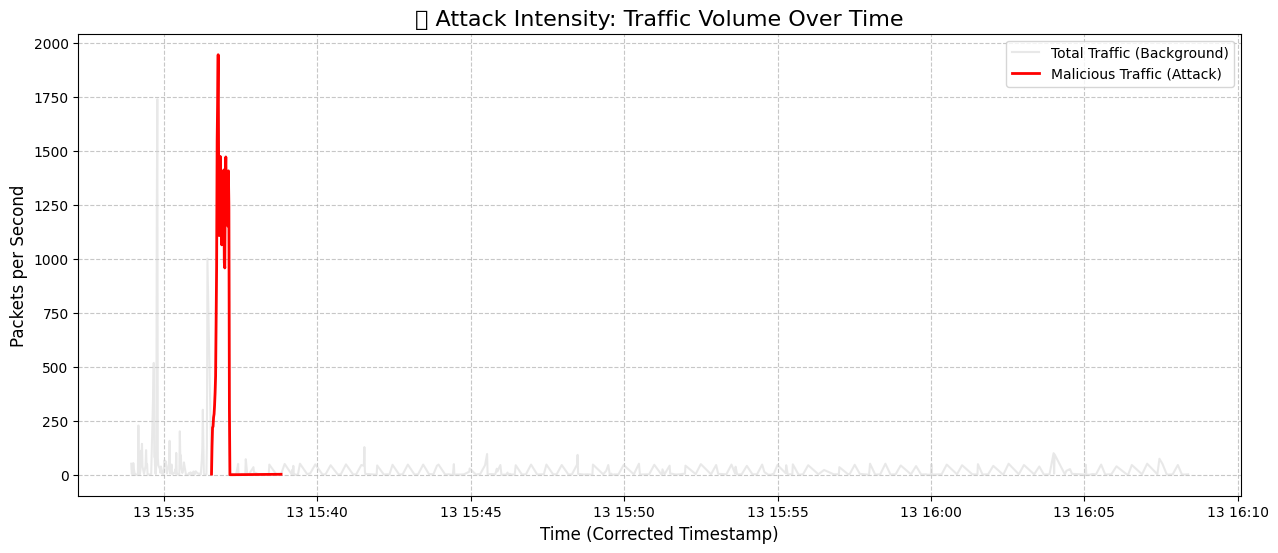

📊 Chart generated successfully using the corrected 'timestamp' column.


In [20]:

traffic_per_sec = ml.groupby('timestamp').size()
malicious_per_sec = ml[ml['is_malicious'] == 1].groupby('timestamp').size()

plt.figure(figsize=(15, 6))

plt.plot(traffic_per_sec.index, traffic_per_sec.values, 
         color='lightgray', label='Total Traffic (Background)', alpha=0.5)

plt.plot(malicious_per_sec.index, malicious_per_sec.values, 
         color='red', linewidth=2, label='Malicious Traffic (Attack)')

plt.title('🚨 Attack Intensity: Traffic Volume Over Time', fontsize=16)
plt.xlabel('Time (Corrected Timestamp)', fontsize=12)
plt.ylabel('Packets per Second', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

print("📊 Chart generated successfully using the corrected 'timestamp' column.")

In [21]:

final_cols = [
    'timestamp',            
    'src_ip', 'src_role',   
    'dst_ip', 'dst_role',   
    'src_port', 'dst_port',
    'protocol',            
    'packet_length',       
    'direction',           
    'is_malicious',        
    'attack_stage'          
]

final_export = ml[final_cols]

final_export.to_csv('../dashboard/malware_traffic_Master.csv', index=False)

print("💾 Final Master File Saved: malware_traffic_Master.csv")
print(f"Rows: {len(final_export)}, Columns: {len(final_export.columns)}")

💾 Final Master File Saved: malware_traffic_Master.csv
Rows: 48615, Columns: 12
